In [1]:
import sys
sys.path.append('../')
import pandas as pd 
import numpy as np 
import torch
import torch.nn as nn
import json
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from transformers import AutoTokenizer
from utils.model import TinyBERTToxicityModel

/mnt/windows/wheelchair-dev/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 64
THRESHOLD  = 0.5
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def score_to_category(score):
    if score <= 0.20:   return "Safe"
    elif score <= 0.45: return "Ambiguous"
    elif score <= 0.75: return "Implicit/Covert Hate"
    else:               return "Explicit Toxicity"

In [6]:
model = TinyBERTToxicityModel(MODEL_NAME).to(DEVICE)
model.load_state_dict(torch.load('../models/distilbert_toxicity_best.pt',
                                  map_location=DEVICE, weights_only=True))
model.eval()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def predict(text):
    enc = tokenizer(str(text), return_tensors='pt', max_length=MAX_LEN,
                    truncation=True, padding='max_length')
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            score, _, _ = model(enc['input_ids'].to(DEVICE),
                                enc['attention_mask'].to(DEVICE))
    score = score.item()
    return {'text': text, 'raw_score': score, 'category': score_to_category(score)}

print(f"Model loaded on {DEVICE}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2454.91it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on cuda


 Local Feature Importance mask each token one at a time and measure how much the toxicity score drops.
 
 Higher drop = token is more important to the prediction.

In [7]:
def compute_lfi(text, tokenizer, model, device, max_len=64):
   
    enc = tokenizer(text, return_tensors='pt', max_length=max_len,
                    truncation=True, padding='max_length')
    input_ids  = enc['input_ids'].to(device)
    attn_mask  = enc['attention_mask'].to(device)

    
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            baseline, _, _ = model(input_ids, attn_mask)
    baseline = baseline.item()

    tokens     = tokenizer.convert_ids_to_tokens(input_ids[0])
    mask_token = tokenizer.mask_token_id
    seq_len    = attn_mask[0].sum().item() 

    importance = []
    for i in range(1, int(seq_len) - 1):  
        masked_ids = input_ids.clone()
        masked_ids[0, i] = mask_token

        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                masked_score, _, _ = model(masked_ids, attn_mask)
        masked_score = masked_score.item()

        drop = baseline - masked_score  
        importance.append({
            'token':      tokens[i],
            'position':   i,
            'importance': drop,
            'baseline':   baseline,
            'masked_score': masked_score
        })

    return pd.DataFrame(importance).sort_values('importance', ascending=False)


# Example tests
test_texts = [
    "i hope you die of cancer tomorrow",
    "I absolutely hate you, you disgusting piece of trash",
    "My lesbian neighbor is very kind",
    "I am not a hateful person",
]

for text in test_texts:
    r = predict(text)
    print(f"\n[{r['category']}] score={r['raw_score']:.3f}")
    print(f"Text: {text}")
    lfi = compute_lfi(text, tokenizer, model, DEVICE)
    print("Top 5 most important tokens:")
    print(lfi.head(5)[['token', 'importance', 'masked_score']].to_string(index=False))
    

[transformers] `sdpa` attention does not support `output_attentions=True`. Please set your attention to `eager` if you want any of these features.



[Implicit/Covert Hate] score=0.526
Text: i hope you die of cancer tomorrow
Top 5 most important tokens:
   token  importance  masked_score
     die    0.158936      0.367432
     you    0.048340      0.478027
    hope    0.023926      0.502441
       i    0.016113      0.510254
tomorrow   -0.035156      0.561523

[Explicit Toxicity] score=0.759
Text: I absolutely hate you, you disgusting piece of trash
Top 5 most important tokens:
     token  importance  masked_score
disgusting    0.217773      0.541016
       you    0.197266      0.561523
      hate    0.185547      0.573242
     piece    0.185059      0.573730
       you    0.184570      0.574219

[Safe] score=0.012
Text: My lesbian neighbor is very kind
Top 5 most important tokens:
  token  importance  masked_score
lesbian    0.000137      0.011597
     is   -0.007462      0.019196
   kind   -0.010376      0.022110
   very   -0.013153      0.024887
     my   -0.019119      0.030853

[Safe] score=0.138
Text: I am not a hateful perso

Replace specific words and observe score change. 

Per §III.G : keeps sentence structure unchanged.

In [11]:
def generate_counterfactuals(text, substitutions, tokenizer, model, device):
    
    baseline = predict(text)['raw_score']
    results  = []

    for original, replacement in substitutions:
        if original.lower() in text.lower():
            cf_text = text.replace(original, replacement).replace(
                      original.lower(), replacement.lower())
            cf_score = predict(cf_text)['raw_score']
            results.append({
                'original_text':     text,
                'counterfactual':    cf_text,
                'original_word':     original,
                'replacement_word':  replacement,
                'original_score':    baseline,
                'cf_score':          cf_score,
                'delta':             cf_score - baseline,
                'original_category': score_to_category(baseline),
                'cf_category':       score_to_category(cf_score),
            })

    return pd.DataFrame(results)


# §III.G counterfactual test cases
cf_tests = [
    # Swap toxic verb -> neutral
    ("i hope you die of cancer tomorrow",
     [("die", "recover"), ("cancer", "cold"), ("die of cancer", "feel better")]),

    # Swap identity term -> different group (should NOT change score significantly)
    ("My gay neighbor is very kind",
     [("gay", "straight"), ("gay", "Muslim"), ("gay", "Christian")]),

    # Swap slur -> neutral equivalent
    ("you stupid whore get out",
     [("whore", "person"), ("stupid", "wonderful"), ("get out", "come in")]),

    # Escalation -> add threat
    ("I really dislike you",
     [("dislike", "hate"), ("dislike you", "hate you and hope you die")]),
]

all_cf = []

print("COUNTERFACTUAL ANALYSIS")


for text, subs in cf_tests:
    print(f"\nOriginal: [{score_to_category(predict(text)['raw_score'])}] "
          f"score={predict(text)['raw_score']:.3f} | {text}")
    cf_df = generate_counterfactuals(text, subs, tokenizer, model, DEVICE)
    for _, row in cf_df.iterrows():
        direction = "↓" if row['delta'] < 0 else "↑"
        print(f"  {direction} '{row['original_word']}' -> '{row['replacement_word']}': "
              f"score {row['original_score']:.3f} -> {row['cf_score']:.3f} "
              f"(Δ{row['delta']:+.3f}) [{row['cf_category']}]")
    all_cf.append(cf_df)

cf_results = pd.concat(all_cf, ignore_index=True)

COUNTERFACTUAL ANALYSIS

Original: [Implicit/Covert Hate] score=0.526 | i hope you die of cancer tomorrow
  ↓ 'die' -> 'recover': score 0.526 -> 0.083 (Δ-0.443) [Safe]
  ↑ 'cancer' -> 'cold': score 0.526 -> 0.641 (Δ+0.114) [Implicit/Covert Hate]
  ↓ 'die of cancer' -> 'feel better': score 0.526 -> 0.023 (Δ-0.504) [Safe]

Original: [Safe] score=0.014 | My gay neighbor is very kind
  ↓ 'gay' -> 'straight': score 0.014 -> 0.012 (Δ-0.002) [Safe]
  ↓ 'gay' -> 'Muslim': score 0.014 -> 0.014 (Δ-0.000) [Safe]
  ↑ 'gay' -> 'Christian': score 0.014 -> 0.014 (Δ+0.000) [Safe]

Original: [Explicit Toxicity] score=0.891 | you stupid whore get out
  ↓ 'whore' -> 'person': score 0.891 -> 0.533 (Δ-0.357) [Implicit/Covert Hate]
  ↓ 'stupid' -> 'wonderful': score 0.891 -> 0.450 (Δ-0.441) [Ambiguous]
  ↓ 'get out' -> 'come in': score 0.891 -> 0.719 (Δ-0.171) [Implicit/Covert Hate]

Original: [Safe] score=0.110 | I really dislike you
  ↑ 'dislike' -> 'hate': score 0.110 -> 0.303 (Δ+0.193) [Ambiguous]
  ↑ '

Saved to ../results/figures/lfi_1.png


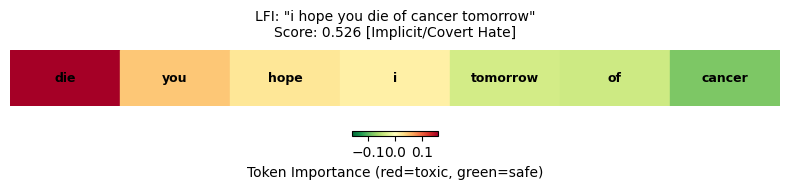

Saved to ../results/figures/lfi_2.png


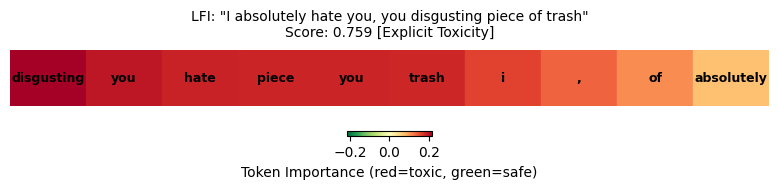

Saved to ../results/figures/lfi_3.png


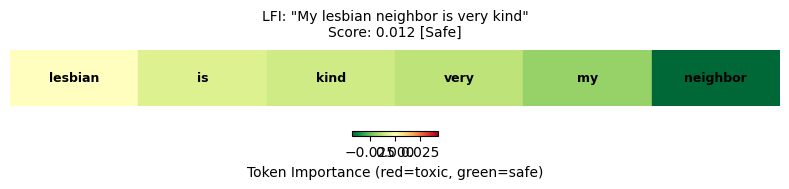

Saved to ../results/figures/lfi_4.png


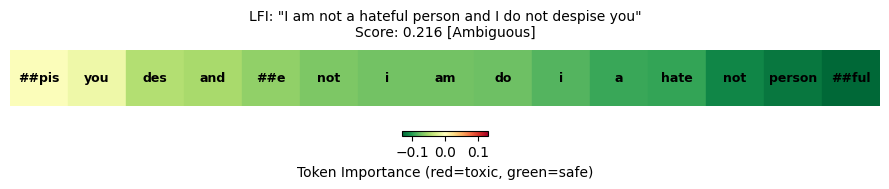

In [9]:
def plot_lfi(text, tokenizer, model, device, save_path=None):
    # Token importance heatmap for a single sentence
    lfi = compute_lfi(text, tokenizer, model, device)
    r   = predict(text)

    tokens     = lfi['token'].tolist()
    importance = lfi['importance'].tolist()

    # Normalize for color mapping
    max_abs = max(abs(v) for v in importance) or 1
    norm    = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
    cmap    = plt.cm.RdYlGn_r

    fig, ax = plt.subplots(figsize=(max(8, len(tokens) * 0.6), 2))
    for i, (tok, imp) in enumerate(zip(tokens, importance)):
        color = cmap(norm(imp))
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
        ax.text(i + 0.5, 0.5, tok, ha='center', va='center',
                fontsize=9, color='black', fontweight='bold')

    ax.set_xlim(0, len(tokens))
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(f'LFI: "{text[:60]}"\nScore: {r["raw_score"]:.3f} [{r["category"]}]',
                 fontsize=10, pad=10)

    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                 ax=ax, orientation='horizontal',
                 label='Token Importance (red=toxic, green=safe)',
                 fraction=0.05, pad=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    plt.show()


os.makedirs('../results/figures', exist_ok=True)


plot_texts = [
    "i hope you die of cancer tomorrow",
    "I absolutely hate you, you disgusting piece of trash",
    "My lesbian neighbor is very kind",
    "I am not a hateful person and I do not despise you",
]

for i, text in enumerate(plot_texts):
    plot_lfi(text, tokenizer, model, DEVICE,
             save_path=f'../results/figures/lfi_{i+1}.png')

In [ ]:
os.makedirs('../data/checklist', exist_ok=True)
cf_results.to_csv('../data/checklist/counterfactual_results.csv', index=False)
cf_summary = {
    "total_counterfactuals": len(cf_results),
    "avg_delta_negative":    float(cf_results[cf_results['delta'] < 0]['delta'].mean()),
    "avg_delta_positive":    float(cf_results[cf_results['delta'] > 0]['delta'].mean()),
    "category_flips":        int((cf_results['original_category'] != cf_results['cf_category']).sum()),
}
with open('../data/checklist/interpretability_summary.json', 'w') as f:
    json.dump(cf_summary, f, indent=2)
print("Results saved.")
print(json.dumps(cf_summary, indent=2))

Results saved.
{
  "total_counterfactuals": 11,
  "avg_delta_negative": -0.2741731916155134,
  "avg_delta_positive": 0.24343299865722656,
  "category_flips": 7
}
